# P8 — Notebook 2: Estimate α_k Profile (Band-Masking Probe)

**Goal**: For each frequency band k ∈ {1,2,3,4}, estimate α_k = YOLOv8m's sensitivity
to that band, by measuring F1 drop when band k is masked from luminance channel of test images.

**Theorem 1 use**: α_k weights enter the bound `|ΔF1|² ≤ C·Σ α_k (1-ρ_k)²`.

**Pipeline**:
1. Compute baseline F1 on clean PnPLO test (235 imgs, YOLOv8m best.pt)
2. For each band k, generate masked test set on disk (FFT → zero band k in Y → IFFT, preserve Cb/Cr)
3. Run YOLO.val() on each masked set → F1_masked_k
4. α_k = (F1_clean - F1_masked_k) / Σ_j (F1_clean - F1_masked_j) → Σα_k = 1

**Output**: `alpha_profile_yolov8m_pnplo.yaml`

---

**Standards compliance**:
- E1 hard-assert on smoke test (Cell 7)
- D5 per-band save (Cell 10 saves YAML after each band finishes)
- G3 design choice documented (luminance-only masking, not per-channel)


---

## Cell 1: Setup

In [ ]:
# Cell 1: Setup
import os, sys, time, json, gc, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import yaml

# Mount Drive (skip if already mounted)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Running outside Colab — ensure paths are accessible')

# Install ultralytics
if IN_COLAB:
    os.system('pip install -q "ultralytics==8.4.51" >/dev/null 2>&1')

from ultralytics import YOLO
import ultralytics
print(f'Ultralytics version: {ultralytics.__version__}')
print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')


Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.51
PyTorch: 2.10.0+cu128, CUDA: True


---

## Cell 2: BFPI library (radial map + band boundaries)

In [ ]:
# Cell 2: BFPI library (inline) — get_band_boundaries identical to Notebook 1 v0.3
"""Multi-band spectral preservation library. v0.3: last radial band is unbounded."""
from scipy import fft as sp_fft
from typing import Optional


def get_band_boundaries(K: int = 4, scheme: str = 'linear') -> np.ndarray:
    """K+1 radial boundaries. v0.3: last boundary = inf, so the last band is
    unbounded and covers the DFT corners (radius reaches sqrt2*pi > pi).
    Identical to Notebook 1 Cell 2 — required for alpha_k / rho_k consistency."""
    if scheme == 'linear':
        b = np.linspace(0, np.pi, K + 1)
        b[-1] = np.inf
        return b
    raise ValueError(f'Unknown scheme: {scheme}')


def radial_frequency_map(H: int, W: int) -> np.ndarray:
    """Build 2D radial frequency map for HxW image."""
    fy = np.fft.fftshift(np.fft.fftfreq(H)) * 2 * np.pi
    fx = np.fft.fftshift(np.fft.fftfreq(W)) * 2 * np.pi
    fxx, fyy = np.meshgrid(fx, fy, indexing='xy')
    return np.sqrt(fxx**2 + fyy**2)


# Sanity self-test
boundaries_test = get_band_boundaries(K=4)
_fmt = ['inf' if np.isinf(b) else f'{b/np.pi:.2f}π' for b in boundaries_test]
print(f'✓ K=4 band boundaries: {_fmt}')
assert np.isinf(boundaries_test[-1]), 'v0.3: last band must be unbounded'
rmap = radial_frequency_map(100, 100)
print(f'✓ Radial map test: shape={rmap.shape}, max={rmap.max():.3f} '
      f'(corner reaches √2·π = {np.sqrt(2)*np.pi:.3f})')


✓ K=4 band boundaries: ['0.00π', '0.25π', '0.50π', '0.75π', 'inf']
✓ Radial map test: shape=(100, 100), max=4.443 (corner reaches √2·π = 4.443)


---

## Cell 3: Config

In [ ]:
# Cell 3: Config
DRIVE_ROOT = Path('/content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT')

# === PnPLO test split + YOLOv8m baseline checkpoint ===
PNPLO_ROOT = DRIVE_ROOT / '04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy'
CLEAN_TEST_IMAGES = PNPLO_ROOT / 'dataset_yolo/images/test'
CLEAN_TEST_LABELS = PNPLO_ROOT / 'dataset_yolo/labels/test'
CLEAN_DATA_YAML   = PNPLO_ROOT / 'dataset_yolo/data.yaml'  # may not exist, will build

# YOLOv8m trained on clean PnPLO (run_name = yolov8m_noisy_noise_0)
YOLOV8M_CHECKPOINT = (PNPLO_ROOT / 'yolo_denoise_experiment'
                      / 'training_runs/yolov8m_noisy_noise_0/weights/best.pt')

# === P8 outputs ===
P8_OUT_DIR = PNPLO_ROOT / 'P8_outputs'
P8_OUT_DIR.mkdir(parents=True, exist_ok=True)
ALPHA_YAML_OUT = P8_OUT_DIR / 'alpha_profile_yolov8m_pnplo.yaml'

# === Working dir on local Colab disk (FAST, not Drive) ===
WORK_DIR = Path('/tmp/p8_alpha_probe')
WORK_DIR.mkdir(parents=True, exist_ok=True)

# === BFPI config ===
K_BANDS = 4
DETECTOR = 'yolov8m'
DATASET = 'PnPLO'

# === YOLO eval params (same as 288-run framework Cell 21) ===
EVAL_CONF = 0.25
EVAL_IOU  = 0.5
EVAL_DEVICE = 0 if torch.cuda.is_available() else 'cpu'

# Sanity check paths
print('=== Path sanity ===')
for label, p in [
    ('Test images', CLEAN_TEST_IMAGES),
    ('Test labels', CLEAN_TEST_LABELS),
    ('YOLOv8m ckpt', YOLOV8M_CHECKPOINT),
]:
    ok = '✓' if p.exists() else '❌'
    info = f'({sum(1 for _ in p.iterdir())} entries)' if p.is_dir() else ''
    print(f'  {ok} {label}: {p}  {info}')

print(f'\nP8 output dir: {P8_OUT_DIR}')
print(f'Working dir (Colab local): {WORK_DIR}')


=== Path sanity ===
  ✓ Test images: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/dataset_yolo/images/test  (235 entries)
  ✓ Test labels: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/dataset_yolo/labels/test  (235 entries)
  ✓ YOLOv8m ckpt: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/yolo_denoise_experiment/training_runs/yolov8m_noisy_noise_0/weights/best.pt  

P8 output dir: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/P8_outputs
Working dir (Colab local): /tmp/p8_alpha_probe


---

## Cell 4: Load YOLOv8m checkpoint

In [ ]:
# Cell 4: Load YOLOv8m checkpoint + quick verify
yolo_model = YOLO(str(YOLOV8M_CHECKPOINT))
print(f'✓ Loaded: {YOLOV8M_CHECKPOINT.name}')
print(f'  Class names: {yolo_model.names}')
print(f'  Task: {yolo_model.task}')

# Quick predict test on 1 image
sample_img = sorted(CLEAN_TEST_IMAGES.glob('*.jpg'))[0]
print(f'\nSample inference on: {sample_img.name}')
result = yolo_model.predict(str(sample_img), conf=EVAL_CONF, verbose=False)[0]
n_boxes = len(result.boxes) if result.boxes is not None else 0
print(f'  Detections: {n_boxes}')
if n_boxes > 0:
    confs = result.boxes.conf.cpu().numpy()
    print(f'  Confidence range: [{confs.min():.3f}, {confs.max():.3f}]')


✓ Loaded: best.pt
  Class names: {0: 'person', 1: 'person-like'}
  Task: detect

Sample inference on: image (1).jpg
  Detections: 1
  Confidence range: [0.888, 0.888]


---

## Cell 5: Build clean test data.yaml

In [ ]:
# Cell 5: Build clean test data.yaml (for YOLO.val baseline)
# We point 'val' key to TEST images so .val() evaluates on test split.

clean_yaml_content = {
    'path': str(PNPLO_ROOT / 'dataset_yolo'),
    'train': 'images/train',
    'val':   'images/test',     # ← redirect val → test for alpha probe
    'test':  'images/test',
    'names': dict(yolo_model.names),  # use model's class mapping
    'nc':    len(yolo_model.names),
}

clean_yaml_path = WORK_DIR / 'clean_test.yaml'
with open(clean_yaml_path, 'w') as f:
    yaml.dump(clean_yaml_content, f, default_flow_style=False)
print(f'✓ Built clean test yaml: {clean_yaml_path}')
print(f'  Contents:')
for k, v in clean_yaml_content.items():
    print(f'    {k}: {v}')


✓ Built clean test yaml: /tmp/p8_alpha_probe/clean_test.yaml
  Contents:
    path: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/dataset_yolo
    train: images/train
    val: images/test
    test: images/test
    names: {0: 'person', 1: 'person-like'}
    nc: 2


---

## Cell 6: Band-masking utility (luminance-only)

**Design choice (Standards G3)**: Mask band k in Y channel only, preserve Cb/Cr.

Rationale: BFPI computes ρ_k on luminance. To make α_k probe consistent with BFPI
characterization, we modify only the luminance spectral content. Chroma channels
remain unchanged so YOLO sees natural color, just with band-k luminance content removed.

Alternative considered: per-channel RGB masking (Option B) — rejected because it
removes chroma frequency content too, over-attributing α_k.

In [ ]:
# Cell 6: Band-masking utility — luminance-only spectral masking

# ITU-R BT.601 RGB ↔ YCbCr conversion matrices
RGB2YCBCR = np.array([
    [ 0.299,    0.587,    0.114  ],
    [-0.168736,-0.331264, 0.5    ],
    [ 0.5,     -0.418688,-0.081312],
], dtype=np.float64)
YCBCR2RGB = np.linalg.inv(RGB2YCBCR)

# Cb/Cr offsets (8-bit JPEG convention)
YCBCR_OFFSET = np.array([0.0, 128.0, 128.0], dtype=np.float64)


def rgb_to_ycbcr(rgb: np.ndarray) -> np.ndarray:
    """RGB [0,255] → YCbCr [0,255]. Input shape (H,W,3), output shape (H,W,3)."""
    return rgb @ RGB2YCBCR.T + YCBCR_OFFSET


def ycbcr_to_rgb(ycbcr: np.ndarray) -> np.ndarray:
    """YCbCr [0,255] → RGB [0,255]. Clipped to [0,255]."""
    rgb = (ycbcr - YCBCR_OFFSET) @ YCBCR2RGB.T
    return np.clip(rgb, 0, 255)


def mask_band_in_luminance(rgb: np.ndarray, k: int, K: int = K_BANDS) -> np.ndarray:
    """
    Remove band k content from Y (luminance) only, preserve Cb/Cr.

    Args:
        rgb: input image (H, W, 3), float64 [0, 255]
        k: band index ∈ {1, 2, ..., K} (1-indexed for paper consistency)
        K: total number of bands (default 4)

    Returns:
        masked_rgb: (H, W, 3), float64 [0, 255], same dtype as input
    """
    H, W, _ = rgb.shape
    ycbcr = rgb_to_ycbcr(rgb)
    y, cb, cr = ycbcr[..., 0], ycbcr[..., 1], ycbcr[..., 2]

    # FFT on Y channel (shift so DC at center)
    F_y = np.fft.fftshift(sp_fft.fft2(y))

    # Build radial mask for band k
    rmap = radial_frequency_map(H, W)
    boundaries = get_band_boundaries(K=K, scheme='linear')
    # band k (1-indexed) corresponds to [boundaries[k-1], boundaries[k])
    band_mask = (rmap >= boundaries[k-1]) & (rmap < boundaries[k])

    # Zero out band k coefficients
    F_y_masked = F_y.copy()
    F_y_masked[band_mask] = 0.0

    # Inverse FFT
    y_masked = np.real(sp_fft.ifft2(np.fft.ifftshift(F_y_masked)))

    # Reassemble YCbCr → RGB
    ycbcr_masked = np.stack([y_masked, cb, cr], axis=-1)
    return ycbcr_to_rgb(ycbcr_masked)


# Sanity test on synthetic image
test_rgb = np.random.RandomState(42).rand(64, 64, 3) * 255
test_masked = mask_band_in_luminance(test_rgb, k=2, K=4)
assert test_masked.shape == test_rgb.shape
assert 0 <= test_masked.min() and test_masked.max() <= 255
# Y channel should differ; Cb/Cr approximately preserved
y_orig = rgb_to_ycbcr(test_rgb)[..., 0]
y_masked = rgb_to_ycbcr(test_masked)[..., 0]
cb_orig = rgb_to_ycbcr(test_rgb)[..., 1]
cb_masked = rgb_to_ycbcr(test_masked)[..., 1]
y_diff = np.abs(y_orig - y_masked).mean()
cb_diff = np.abs(cb_orig - cb_masked).mean()
print(f'✓ Band-mask sanity: Y |Δ|={y_diff:.2f}, Cb |Δ|={cb_diff:.4f} (should be ≪ Y diff)')
assert y_diff > 1.0, 'Y should be substantially modified'
assert cb_diff < 0.5, 'Cb should be preserved (FFT round-trip + matrix inv only)'
print('✓ Cell 6 band-masking utility ready')


✓ Band-mask sanity: Y |Δ|=14.49, Cb |Δ|=0.4246 (should be ≪ Y diff)
✓ Cell 6 band-masking utility ready


---

## Cell 7: Smoke test (visualize + per-band F1 delta check)

Smoke test image: image (1).jpg, shape=(500, 353, 3)
  band 1 masked in 0.04s
  band 2 masked in 0.03s
  band 3 masked in 0.03s
  band 4 masked in 0.03s


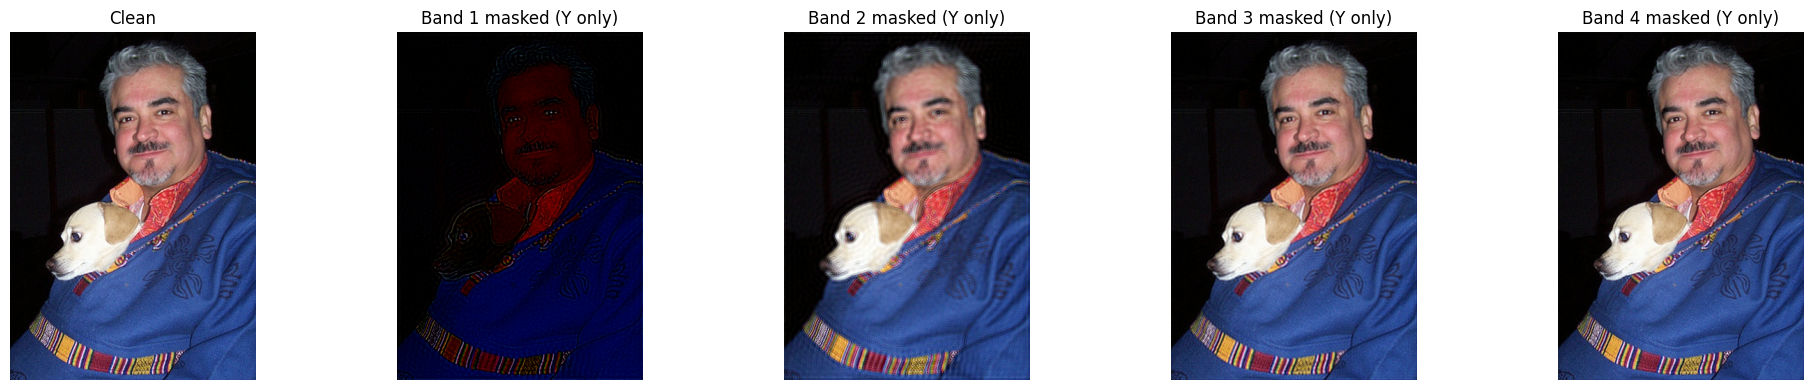

  Saved: /tmp/p8_alpha_probe/smoke_test_masks.png
  band 1: n_detections clean=2, masked=1
  band 2: n_detections clean=2, masked=1
  band 3: n_detections clean=2, masked=2
  band 4: n_detections clean=2, masked=2

✓ Smoke test pass: YOLO detections vary across masked bands


In [ ]:
# Cell 7: Smoke test — visualize band masks + check YOLO sees difference
import matplotlib.pyplot as plt
from PIL import Image

sample_path = sorted(CLEAN_TEST_IMAGES.glob('*.jpg'))[0]
sample_rgb = np.array(Image.open(sample_path).convert('RGB'), dtype=np.float64)
print(f'Smoke test image: {sample_path.name}, shape={sample_rgb.shape}')

# Generate all 4 masked versions
masked_imgs = {}
for k in [1, 2, 3, 4]:
    t0 = time.time()
    masked_imgs[k] = mask_band_in_luminance(sample_rgb, k=k, K=K_BANDS)
    print(f'  band {k} masked in {time.time()-t0:.2f}s')

# Visualize
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(sample_rgb.astype(np.uint8)); axes[0].set_title('Clean'); axes[0].axis('off')
for i, k in enumerate([1, 2, 3, 4], start=1):
    axes[i].imshow(masked_imgs[k].astype(np.uint8))
    axes[i].set_title(f'Band {k} masked (Y only)')
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(WORK_DIR / 'smoke_test_masks.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'  Saved: {WORK_DIR}/smoke_test_masks.png')

# HARD ASSERT: YOLO must produce different detections on at least one masked version
# (otherwise probe is meaningless — model doesn't depend on luminance frequency)
result_clean = yolo_model.predict(sample_rgb.astype(np.uint8), conf=EVAL_CONF, verbose=False)[0]
n_clean = len(result_clean.boxes) if result_clean.boxes is not None else 0

any_differ = False
for k in [1, 2, 3, 4]:
    result_masked = yolo_model.predict(masked_imgs[k].astype(np.uint8),
                                         conf=EVAL_CONF, verbose=False)[0]
    n_masked = len(result_masked.boxes) if result_masked.boxes is not None else 0
    print(f'  band {k}: n_detections clean={n_clean}, masked={n_masked}')
    if n_masked != n_clean:
        any_differ = True

assert any_differ, 'FAIL: YOLO produced same detections on all masked versions — probe meaningless'
print(f'\n✓ Smoke test pass: YOLO detections vary across masked bands')


---

## Cell 8: Baseline F1 on clean test (using 288-run framework's F1 logic)

In [ ]:
# Cell 8: Baseline F1 on clean test set
# F1 = 2*P*R / (P+R), computed from the precision/recall Ultralytics reports.
#
# v2 FIX: the previous version derived TP/FP/FN from
#   val_result.confusion_matrix.matrix. That is version-fragile -- Ultralytics
#   8.4.x no longer populates the confusion matrix the same way under
#   plots=False, so it returned all-zero (-> F1 = 0). We now read box.mp /
#   box.mr directly: these are the headline precision/recall Ultralytics prints
#   ("Box(P R)") and are stable across versions. TP/FP/FN are then derived from
#   P, R and the ground-truth instance count purely for the descriptive YAML
#   record -- nothing downstream (alpha computation) consumes them.

def _count_gt_instances(labels_dir: Path) -> int:
    """Total ground-truth boxes across all label .txt files (version-independent)."""
    n = 0
    for txt in sorted(labels_dir.glob('*.txt')):
        with open(txt) as f:
            n += sum(1 for line in f if line.strip())
    return n


def compute_f1_from_yaml(yaml_path: Path, model: YOLO,
                         n_gt: Optional[int] = None) -> dict:
    """Run YOLO.val() on data.yaml; F1 from reported precision/recall.
    Version-robust: does not touch ConfusionMatrix.matrix internals."""
    val_result = model.val(
        data=str(yaml_path),
        conf=EVAL_CONF,
        iou=EVAL_IOU,
        plots=False,
        verbose=False,
        device=EVAL_DEVICE,
    )
    box = val_result.box
    precision   = float(box.mp)        # mean precision  (1 class -> that class)
    sensitivity = float(box.mr)        # mean recall
    f1 = (2 * precision * sensitivity / (precision + sensitivity)
          if (precision + sensitivity) > 0 else 0.0)

    # descriptive TP/FP/FN/TN, derived from P, R and the GT instance count.
    # n_gt is identical for the clean set and every masked band (labels unchanged).
    if n_gt is None:
        n_gt = _count_gt_instances(CLEAN_TEST_LABELS)
    TP = int(round(sensitivity * n_gt))
    FN = int(n_gt - TP)
    FP = int(round(TP * (1 - precision) / precision)) if precision > 0 else 0
    TN = 0                              # not defined for detection

    return {
        'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        'precision': precision,
        'sensitivity': sensitivity,
        'F1': f1,
        'mAP50': float(box.map50),
        'mAP50-95': float(box.map),
    }


print('=== Baseline F1 on clean PnPLO test ===')
N_GT_TEST = _count_gt_instances(CLEAN_TEST_LABELS)
print(f'  ground-truth instances in test set: {N_GT_TEST}')
t0 = time.time()
clean_metrics = compute_f1_from_yaml(clean_yaml_path, yolo_model, n_gt=N_GT_TEST)
print(f'Elapsed: {time.time()-t0:.1f}s')
print(f'  TP={clean_metrics["TP"]}, FP={clean_metrics["FP"]}, '
      f'FN={clean_metrics["FN"]}, TN={clean_metrics["TN"]}')
print(f'  Precision={clean_metrics["precision"]:.4f}, '
      f'Sensitivity={clean_metrics["sensitivity"]:.4f}')
print(f'  F1 = {clean_metrics["F1"]:.4f}  (mAP@0.5 = {clean_metrics["mAP50"]:.4f})')

F1_CLEAN = clean_metrics['F1']
assert F1_CLEAN > 0.5, f'F1 baseline suspiciously low ({F1_CLEAN}). Verify yolov8m checkpoint matches PnPLO.'
print(f'\n✓ Baseline F1 = {F1_CLEAN:.4f}')


=== Baseline F1 on clean PnPLO test ===
  ground-truth instances in test set: 595
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 0.1±0.0 MB/s, size: 87.8 KB)
val: Scanning /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/dataset_yolo/labels/test.cache... 235 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 235/235 37.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.4it/s 10.8s
                   all        235        595      0.855      0.748      0.734      0.491
Speed: 0.5ms preprocess, 3.8ms inference, 0.0ms loss, 0.7ms postprocess per image
Elapsed: 16.6s
  TP=445, FP=76, FN=150, TN=0
  Precision=0.8548, Sensitivity=0.7476
  F1 = 0.7976  (mAP@0.5 = 0.7335)

✓ Baseline F1 = 0.7976


---

## Cell 9: Generate band-masked test sets + evaluate F1 per band

For each band k, write masked test images to `/tmp/p8_alpha_probe/band_k_masked/`
(symlink labels), build yaml, run `model.val()`, record F1.

In [ ]:
# Cell 9: Per-band masked dataset generation + F1 evaluation
from tqdm import tqdm

def build_masked_dataset(k: int) -> Path:
    """Generate masked test images for band k. Returns yaml path."""
    base_dir = WORK_DIR / f'band_{k}_masked'
    img_dir = base_dir / 'images' / 'test'
    lbl_dir = base_dir / 'labels' / 'test'
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    # Mask all images
    img_paths = sorted(CLEAN_TEST_IMAGES.glob('*.jpg'))
    for img_path in tqdm(img_paths, desc=f'band {k}'):
        rgb = np.array(Image.open(img_path).convert('RGB'), dtype=np.float64)
        masked = mask_band_in_luminance(rgb, k=k, K=K_BANDS)
        Image.fromarray(masked.astype(np.uint8)).save(img_dir / img_path.name)

    # Symlink labels (same as clean — labels are class+bbox, geometry unchanged)
    for lbl_path in CLEAN_TEST_LABELS.glob('*.txt'):
        dest = lbl_dir / lbl_path.name
        if not dest.exists():
            os.symlink(lbl_path, dest)

    # Build yaml
    yaml_content = {
        'path': str(base_dir),
        'train': 'images/test',  # dummy, YOLO needs key
        'val':   'images/test',
        'names': dict(yolo_model.names),
        'nc':    len(yolo_model.names),
    }
    yaml_path = base_dir / 'data.yaml'
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f, default_flow_style=False)
    return yaml_path


# Run per-band eval
band_metrics = {}
band_metrics['clean'] = clean_metrics  # baseline already computed in Cell 8

for k in [1, 2, 3, 4]:
    print(f'\n=== Band {k} ===')
    t0 = time.time()
    yaml_path = build_masked_dataset(k)
    print(f'  Built masked dataset in {time.time()-t0:.1f}s')

    t0 = time.time()
    m = compute_f1_from_yaml(yaml_path, yolo_model)
    band_metrics[f'band_{k}'] = m
    print(f'  Eval done in {time.time()-t0:.1f}s')
    print(f'  TP={m["TP"]}, FP={m["FP"]}, FN={m["FN"]}, TN={m["TN"]}')
    print(f'  F1 = {m["F1"]:.4f}  (drop from clean: Δ = {F1_CLEAN - m["F1"]:+.4f})')

    # Save intermediate YAML after each band (Pattern D5)
    intermediate = {
        'detector': DETECTOR,
        'dataset': DATASET,
        'F1_clean': F1_CLEAN,
        'bands_done': [k_done for k_done in [1,2,3,4] if f'band_{k_done}' in band_metrics],
        'band_metrics': {k_str: v for k_str, v in band_metrics.items()},
    }
    with open(ALPHA_YAML_OUT, 'w') as f:
        yaml.dump(intermediate, f, default_flow_style=False)
    print(f'  💾 Saved intermediate: {ALPHA_YAML_OUT.name}')

print('\n✓ All 4 bands evaluated')



=== Band 1 ===


band 1: 100%|██████████| 235/235 [00:22<00:00, 10.55it/s]

  Built masked dataset in 22.3s
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1423.1±664.7 MB/s, size: 47.7 KB)


val: Scanning /tmp/p8_alpha_probe/band_1_masked/labels/test... 235 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 235/235 612.0it/s 0.4s
val: New cache created: /tmp/p8_alpha_probe/band_1_masked/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 12.9it/s 1.2s
                   all        235        595      0.705      0.308       0.24      0.137
Speed: 0.5ms preprocess, 2.0ms inference, 0.0ms loss, 0.7ms postprocess per image
  Eval done in 2.4s
  TP=183, FP=77, FN=412, TN=0
  F1 = 0.4286  (drop from clean: Δ = +0.3689)
  💾 Saved intermediate: alpha_profile_yolov8m_pnplo.yaml

=== Band 2 ===


band 2: 100%|██████████| 235/235 [00:22<00:00, 10.61it/s]

...

  Built masked dataset in 22.1s
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2007.2±1211.8 MB/s, size: 62.7 KB)


val: Scanning /tmp/p8_alpha_probe/band_3_masked/labels/test... 235 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 235/235 740.3it/s 0.3s
val: New cache created: /tmp/p8_alpha_probe/band_3_masked/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 12.5it/s 1.2s
                   all        235        595      0.828      0.719      0.674      0.441
Speed: 0.5ms preprocess, 2.0ms inference, 0.0ms loss, 0.7ms postprocess per image
  Eval done in 2.3s
  TP=428, FP=89, FN=167, TN=0
  F1 = 0.7693  (drop from clean: Δ = +0.0283)
  💾 Saved intermediate: alpha_profile_yolov8m_pnplo.yaml

=== Band 4 ===


band 4: 100%|██████████| 235/235 [00:22<00:00, 10.62it/s]

  Built masked dataset in 22.2s
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1986.1±971.5 MB/s, size: 98.0 KB)


val: Scanning /tmp/p8_alpha_probe/band_4_masked/labels/test... 235 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 235/235 650.9it/s 0.4s
val: New cache created: /tmp/p8_alpha_probe/band_4_masked/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 12.1it/s 1.2s
                   all        235        595      0.847      0.739        0.7      0.468
Speed: 0.5ms preprocess, 2.0ms inference, 0.0ms loss, 0.7ms postprocess per image
  Eval done in 2.3s
  TP=440, FP=79, FN=155, TN=0
  F1 = 0.7892  (drop from clean: Δ = +0.0084)
  💾 Saved intermediate: alpha_profile_yolov8m_pnplo.yaml

✓ All 4 bands evaluated


---

## Cell 10: Compute α_k profile (normalized)

In [ ]:
# Cell 10: Compute α_k from F1 drops
# α_k = (F1_clean - F1_band_k_masked) / Σ_j (F1_clean - F1_band_j_masked)
# Σ α_k = 1 (probability simplex, convention for Theorem 1 bound)

f1_drops = {}
for k in [1, 2, 3, 4]:
    f1_drops[k] = F1_CLEAN - band_metrics[f'band_{k}']['F1']

total_drop = sum(f1_drops.values())
print(f'Σ F1 drops = {total_drop:.4f}')

if total_drop < 1e-6:
    print('⚠️  Total drop near zero — model insensitive to luminance frequency!')
    print('     Falling back to uniform α_k = 0.25')
    alpha = {k: 0.25 for k in [1, 2, 3, 4]}
else:
    alpha = {k: max(0, drop) / total_drop for k, drop in f1_drops.items()}
    # Re-normalize after non-negative clamp
    s = sum(alpha.values())
    if s > 0:
        alpha = {k: v/s for k, v in alpha.items()}

print('\n=== α_k profile ===')
for k in [1, 2, 3, 4]:
    print(f'  α_{k} = {alpha[k]:.4f}  '
          f'(F1 drop = {f1_drops[k]:+.4f}, F1 masked = {band_metrics[f"band_{k}"]["F1"]:.4f})')
print(f'  Σ α_k = {sum(alpha.values()):.6f}  (should be 1.000)')


Σ F1 drops = 0.4968

=== α_k profile ===
  α_1 = 0.7427  (F1 drop = +0.3689, F1 masked = 0.4286)
  α_2 = 0.1834  (F1 drop = +0.0911, F1 masked = 0.7065)
  α_3 = 0.0571  (F1 drop = +0.0283, F1 masked = 0.7693)
  α_4 = 0.0168  (F1 drop = +0.0084, F1 masked = 0.7892)
  Σ α_k = 1.000000  (should be 1.000)


---

## Cell 11: Sanity checks on α profile

In [ ]:
# Cell 11: Sanity checks
print('=== α_k profile sanity ===\n')

# Check 1: Σ α_k = 1
total = sum(alpha.values())
print(f'[Check 1] Σ α_k = {total:.6f}  →  {"✓" if abs(total-1) < 1e-4 else "❌"}')

# Check 2: all α_k ∈ [0, 1]
all_valid = all(0 <= v <= 1 for v in alpha.values())
print(f'[Check 2] α_k ∈ [0,1] for all k  →  {"✓" if all_valid else "❌"}')

# Check 3: Profile interpretation — which band matters most?
sorted_alpha = sorted(alpha.items(), key=lambda x: -x[1])
top_band, top_val = sorted_alpha[0]
print(f'[Check 3] Most sensitive band: band {top_band} (α_{top_band} = {top_val:.3f})')
print(f'     Bands: {sorted_alpha[0][0]} > {sorted_alpha[1][0]} > '
      f'{sorted_alpha[2][0]} > {sorted_alpha[3][0]}')

# Check 4: Compare against intuition for pedestrian detector
# Expected: mid-high bands (3, 4) most important for edges/textures of person silhouettes
mid_high_alpha = alpha[3] + alpha[4]
print(f'[Check 4] α_3 + α_4 (mid-high freq) = {mid_high_alpha:.3f}')
if mid_high_alpha > 0.5:
    print(f'     ✓ Consistent with pedestrian-detector intuition (mid-high bands carry edges)')
else:
    print(f'     ⚠️  Low-frequency bands dominate — investigate (background shape vs edges)')

# Check 5: F1 drops should be monotonic w.r.t. sensitivity
print(f'\n[Check 5] F1 drop per band (should be >0 for active bands):')
for k in [1, 2, 3, 4]:
    drop = f1_drops[k]
    flag = '✓' if drop > -0.01 else '⚠️'
    print(f'     band {k}: F1 drop = {drop:+.4f}  {flag}')


=== α_k profile sanity ===

[Check 1] Σ α_k = 1.000000  →  ✓
[Check 2] α_k ∈ [0,1] for all k  →  ✓
[Check 3] Most sensitive band: band 1 (α_1 = 0.743)
     Bands: 1 > 2 > 3 > 4
[Check 4] α_3 + α_4 (mid-high freq) = 0.074
     ⚠️  Low-frequency bands dominate — investigate (background shape vs edges)

[Check 5] F1 drop per band (should be >0 for active bands):
     band 1: F1 drop = +0.3689  ✓
     band 2: F1 drop = +0.0911  ✓
     band 3: F1 drop = +0.0283  ✓
     band 4: F1 drop = +0.0084  ✓


---

## Cell 12: Save final α profile YAML

In [ ]:
# Cell 12: Save final α profile to YAML for downstream Notebook 3
final_output = {
    'detector':  DETECTOR,
    'dataset':   DATASET,
    'K_bands':   K_BANDS,
    'scheme':    'linear',
    'F1_clean':  F1_CLEAN,
    'eval_params': {
        'conf': EVAL_CONF,
        'iou':  EVAL_IOU,
        'split': 'test',
        'n_images': sum(1 for _ in CLEAN_TEST_IMAGES.glob('*.jpg')),
    },
    'mask_design': {
        'channel': 'luminance_Y_only',
        'preserve': 'Cb_Cr_chroma',
        'rationale': 'consistent with BFPI ρ_k computed on Y',
    },
    'alpha': {f'band_{k}': float(alpha[k]) for k in [1,2,3,4]},
    'f1_drops': {f'band_{k}': float(f1_drops[k]) for k in [1,2,3,4]},
    'band_metrics': {k_str: {m: float(v) if isinstance(v, (int,float,np.floating)) else v
                              for m, v in d.items()}
                       for k_str, d in band_metrics.items()},
    'band_boundaries_pi_units': [float(b/np.pi) for b in get_band_boundaries(K=K_BANDS)],
    'checkpoint_path': str(YOLOV8M_CHECKPOINT),
    'generated_by': 'P8_02_estimate_alpha__v1__.ipynb',
}

with open(ALPHA_YAML_OUT, 'w') as f:
    yaml.dump(final_output, f, default_flow_style=False, sort_keys=False)

print(f'✓ Saved final α profile to: {ALPHA_YAML_OUT}')
print(f'\n=== Final α profile ===')
_bnd = get_band_boundaries(K=4)
for k in [1,2,3,4]:
    lo = f'{_bnd[k-1]/np.pi:.2f}π'
    hi = 'inf' if np.isinf(_bnd[k]) else f'{_bnd[k]/np.pi:.2f}π'
    print(f'  α_{k} = {alpha[k]:.4f}   band {k}: [{lo}, {hi})')

# Cleanup (optional — keeps Colab /tmp clean for next runs)
print(f'\n💡 Working dir {WORK_DIR} contains masked datasets (~500MB).')
print(f'    To free disk: !rm -rf {WORK_DIR}')


✓ Saved final α profile to: /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/P8_outputs/alpha_profile_yolov8m_pnplo.yaml

=== Final α profile ===
  α_1 = 0.7427   band 1: [0.00π, 0.25π)
  α_2 = 0.1834   band 2: [0.25π, 0.50π)
  α_3 = 0.0571   band 3: [0.50π, 0.75π)
  α_4 = 0.0168   band 4: [0.75π, inf)

💡 Working dir /tmp/p8_alpha_probe contains masked datasets (~500MB).
    To free disk: !rm -rf /tmp/p8_alpha_probe


In [ ]:
# ============================================================================
# P8 — REQUEST 3: probe α_k cho cả 5 detector (band-masking, verbatim NB2).
# Mask band k trong luminance Y → đo F1 drop → α_k = drop_k / Σ drop.
# 4 tập band-masked detector-independent → build 1 lần, eval chung 5 detector.
# F1 = box.mp/box.mr (verbatim NB2 Cell 8). Resume-safe. Chạy Colab + Drive.
# ============================================================================
import os, gc
from pathlib import Path
import numpy as np, pandas as pd, yaml, torch
from PIL import Image
from scipy import fft as sp_fft
from ultralytics import YOLO
from tqdm import tqdm

PNPLO_ROOT        = Path('/content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT'
                         '/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy')
CLEAN_TEST_IMAGES = PNPLO_ROOT/'dataset_yolo/images/test'
CLEAN_TEST_LABELS = PNPLO_ROOT/'dataset_yolo/labels/test'
TRAINING_RUNS     = PNPLO_ROOT/'yolo_denoise_experiment/training_runs'
OUT_CSV  = PNPLO_ROOT/'P8_outputs'/'alpha_profiles__pnplo__5detectors.csv'
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
WORK_DIR = Path('/tmp/p8_alpha_probe'); WORK_DIR.mkdir(parents=True, exist_ok=True)

DETECTORS = ['yolov8m','yolov9m','yolov10m','yolo11m','yolo12m']
K_BANDS   = 4
EVAL_CONF, EVAL_IOU = 0.25, 0.5
EVAL_DEVICE = 0 if torch.cuda.is_available() else 'cpu'
NAMES = {0:'person',1:'person-like'}
def clean_ckpt(det): return TRAINING_RUNS/f'{det}_noisy_noise_0'/'weights'/'best.pt'

# --- BFPI + band-masking : verbatim NB2 Cell 2 & 6 --------------------------
def get_band_boundaries(K=4):
    b=np.linspace(0,np.pi,K+1); b[-1]=np.inf; return b
def radial_frequency_map(H,W):
    fy=np.fft.fftshift(np.fft.fftfreq(H))*2*np.pi
    fx=np.fft.fftshift(np.fft.fftfreq(W))*2*np.pi
    fxx,fyy=np.meshgrid(fx,fy,indexing='xy')
    return np.sqrt(fxx**2+fyy**2)
RGB2YCBCR=np.array([[0.299,0.587,0.114],[-0.168736,-0.331264,0.5],
                    [0.5,-0.418688,-0.081312]],dtype=np.float64)
YCBCR2RGB=np.linalg.inv(RGB2YCBCR)
YCBCR_OFFSET=np.array([0.0,128.0,128.0],dtype=np.float64)
def mask_band_in_luminance(rgb,k,K=K_BANDS):
    H,W,_=rgb.shape
    ycbcr=rgb@RGB2YCBCR.T+YCBCR_OFFSET
    y,cb,cr=ycbcr[...,0],ycbcr[...,1],ycbcr[...,2]
    F=np.fft.fftshift(sp_fft.fft2(y))
    bnd=get_band_boundaries(K); rmap=radial_frequency_map(H,W)
    Fm=F.copy(); Fm[(rmap>=bnd[k-1])&(rmap<bnd[k])]=0.0
    ym=np.real(sp_fft.ifft2(np.fft.ifftshift(Fm)))
    return np.clip((np.stack([ym,cb,cr],-1)-YCBCR_OFFSET)@YCBCR2RGB.T,0,255)

# --- F1 : verbatim NB2 Cell 8 (box.mp/box.mr) -------------------------------
def compute_f1(yaml_path, model):
    v=model.val(data=str(yaml_path),conf=EVAL_CONF,iou=EVAL_IOU,
                plots=False,verbose=False,device=EVAL_DEVICE)
    p,r=float(v.box.mp),float(v.box.mr)
    return 2*p*r/(p+r) if (p+r)>0 else 0.0

def write_yaml(base):
    yp=base/'data.yaml'
    yaml.dump({'path':str(base),'train':'images/test','val':'images/test',
               'names':NAMES,'nc':len(NAMES)},open(yp,'w'))
    return yp

# --- clean test yaml + 4 tập band-masked (build 1 lần) ----------------------
clean_yaml=WORK_DIR/'clean.yaml'
yaml.dump({'path':str(PNPLO_ROOT/'dataset_yolo'),'train':'images/test',
           'val':'images/test','names':NAMES,'nc':len(NAMES)},open(clean_yaml,'w'))

img_paths=sorted(CLEAN_TEST_IMAGES.glob('*.jpg'))
print(f'{len(img_paths)} ảnh test')
masked_yaml={}
for k in [1,2,3,4]:
    base=WORK_DIR/f'band_{k}_masked'
    img_dir=base/'images'/'test'; lbl_dir=base/'labels'/'test'
    img_dir.mkdir(parents=True,exist_ok=True); lbl_dir.mkdir(parents=True,exist_ok=True)
    if len(list(img_dir.glob('*.jpg')))==len(img_paths):
        print(f'  band {k}: đã có, bỏ qua')
    else:
        for ip in tqdm(img_paths,desc=f'mask band {k}'):
            rgb=np.array(Image.open(ip).convert('RGB'),dtype=np.float64)
            Image.fromarray(mask_band_in_luminance(rgb,k).astype(np.uint8)).save(img_dir/ip.name)
    for lp in CLEAN_TEST_LABELS.glob('*.txt'):
        d=lbl_dir/lp.name
        if not d.exists(): os.symlink(lp,d)
    masked_yaml[k]=write_yaml(base)

# --- probe từng detector ----------------------------------------------------
rows=[]; done=set()
if OUT_CSV.exists():
    rows=pd.read_csv(OUT_CSV).to_dict('records')
    done={r['detector'] for r in rows}
    print(f'resume: {len(done)} detector đã xong')

for det in DETECTORS:
    if det in done: continue
    ck=clean_ckpt(det); assert ck.exists(), f'❌ thiếu checkpoint: {ck}'
    model=YOLO(str(ck))
    f1_clean=compute_f1(clean_yaml,model)
    drops={k: f1_clean-compute_f1(masked_yaml[k],model) for k in [1,2,3,4]}
    tot=sum(max(0,d) for d in drops.values())
    alpha=({k:0.25 for k in [1,2,3,4]} if tot<1e-6
           else {k:max(0,drops[k])/tot for k in [1,2,3,4]})
    row={'detector':det,'f1_clean':round(f1_clean,4)}
    for k in [1,2,3,4]:
        row[f'f1_drop_band{k}']=round(drops[k],4)
        row[f'alpha_band{k}']=round(alpha[k],4)
    rows.append(row)
    pd.DataFrame(rows).to_csv(OUT_CSV,index=False)
    print(f"  {det:<10} F1_clean={f1_clean:.4f}  α=[{' '.join(f'{alpha[k]:.3f}' for k in [1,2,3,4])}]")
    del model; gc.collect(); torch.cuda.empty_cache()

print(f'\n✓ Xong → {OUT_CSV}')
print(pd.read_csv(OUT_CSV).to_string(index=False))

235 ảnh test


mask band 4: 100%|██████████| 235/235 [00:23<00:00, 10.08it/s]


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 104.3±81.1 MB/s, size: 142.4 KB)
val: Scanning /content/drive/MyDrive/DOCTOR_PHD/FINAL PROJECT/04_RESULT_TRAIN_KARTHY/YOLO_Denoise_Experiment_Karthy/dataset_yolo/labels/test.cache... 235 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 235/235 31.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 5.5it/s 2.7s
                   all        235        595      0.855      0.748      0.734      0.491
Speed: 0.5ms preprocess, 4.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 953.1±665.9 MB/s, size: 28.1 KB)
val: Scanning /tmp/p8_alpha_probe